--- Ejecutando Motor de Confiabilidad Weibull (MLE) ---
Results from Fit_Weibull_2P (95% CI):
Analysis method: Maximum Likelihood Estimation (MLE)
Optimizer: TNC
Failures / Right censored: 200/1836 (90.17682% right censored) 

Parameter  Point Estimate  Standard Error  Lower CI  Upper CI
    Alpha         726.378         50.1656   634.419   831.666
     Beta         1.57392       0.0762105   1.43141    1.7306 

Goodness of fit    Value
 Log-likelihood -1624.17
           AICc  3252.34
            BIC  3263.58
             AD   278.18 


============= RESUMEN TÉCNICO PARA CAPÍTULO 5 ==============
Parámetro Beta (β): 1.57392
Parámetro Alpha (η): 726.378 días
Log-Likelihood: -1624.17
Intervalo Optimizado (Confiabilidad 95%): 110.05 días
Intervalo Optimizado (Confiabilidad 85%): 228.98 días (Estándar RP-1)


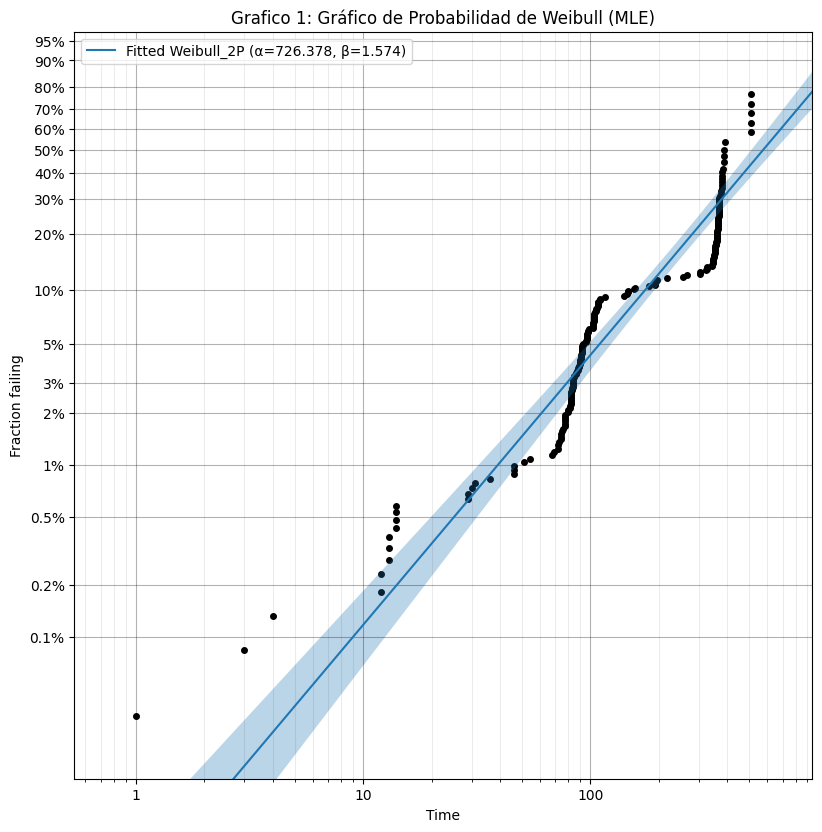

In [6]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from reliability.Fitters import Fit_Weibull_2P

# 1. Configuración de Ruta
ruta = "../../data_drive/TesisII_R2/Fuentes_H_Calculo/SF-TTP-MTBF.xlsx"

print("--- Ejecutando Motor de Confiabilidad Weibull (MLE) ---")

try:
    # 2. Carga y Limpieza de datos
    df = pd.read_excel(ruta, engine='openpyxl')
    df_clean = df.dropna(subset=['Sum of Days_Since_Prev_Calibration']).copy()
    
    tiempos = df_clean['Sum of Days_Since_Prev_Calibration'].astype(float).values
    eventos = df_clean['SF_TTP'].astype(int).values
    
    fallas = tiempos[eventos == 1]
    censuras = tiempos[eventos == 0]

    # Preparamos la figura antes de llamar al modelo
    plt.figure(figsize=(8, 6))

    # 3. Ajuste del Modelo (MLE) - AQUÍ PEDIMOS LA GRÁFICA (show_probability_plot=True)
    model = Fit_Weibull_2P(failures=fallas, right_censored=censuras, print_results=True, show_probability_plot=True)
    
    # 4. Cálculo de los Intervalos
    t_95 = model.distribution.quantile(0.05)
    t_85 = model.distribution.quantile(0.15)
    
    print("\n" + "="*60)
    print(" RESUMEN TÉCNICO PARA CAPÍTULO 5 ".center(60, "="))
    print(f"Parámetro Beta (β): {model.beta:.5f}")
    print(f"Parámetro Alpha (η): {model.alpha:.3f} días")
    print(f"Log-Likelihood: {model.loglik:.2f}")
    print(f"Intervalo Optimizado (Confiabilidad 95%): {t_95:.2f} días")
    print(f"Intervalo Optimizado (Confiabilidad 85%): {t_85:.2f} días (Estándar RP-1)")
    print("="*60)

    # 5. Mostrar la Gráfica
    # (Como la gráfica ya se generó arriba, solo le ponemos título y la mostramos)
    plt.title('Grafico 1: Gráfico de Probabilidad de Weibull (MLE)')
    plt.show()

except Exception as e:
    print(f"❌ Error al procesar: {e}")